# Synthetic motif discovery with VICReg and an atomic VN-RevNet

This notebook is an executable, small-scale demonstration of the paper's pipeline:

1. generate local atomic point clouds with random global orientations;
2. construct overlapping, neighbor-centered views;
3. train a shared rotation-aware encoder with VICReg and **no labels**;
4. cluster frozen invariant embeddings with K-Means;
5. verify clustering and SO(3) robustness on held-out clouds.

The full paper benchmark contains BCC, FCC, HCP, and amorphous motifs. This smoke test uses BCC, FCC, and amorphous environments. FCC/HCP separation depends on close-packed stacking across larger neighbor shells and is deliberately left to the full benchmark.

The default uses the current atomic VN-RevNet. A single setting also exposes VN-DGCNN, VN-PointNet, DGCNN, and PointNet ablations. The regular DGCNN/PointNet alternatives are intentionally not rotation invariant; the final SO(3) diagnostic makes that limitation visible.

In [1]:
from pathlib import Path
import math
import sys
import time

import matplotlib.pyplot as plt
from IPython import get_ipython
import numpy as np
import torch
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    confusion_matrix,
    normalized_mutual_info_score,
)
from torch.utils.data import DataLoader, TensorDataset

search_roots = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (
        path
        for path in search_roots
        if (path / "src").is_dir() and (path / "paper" / "main.tex").is_file()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate the PointCloudMaterials repository root. "
        f"Notebook working directory: {Path.cwd()}"
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.models import (
    build_encoder,
    encode_point_clouds,
    prepare_encoder_input,
    split_encoder_output,
)
from src.training_methods.contrastive_learning import VICRegLoss
from src.utils.pointcloud_ops import crop_to_num_points

ipython = get_ipython()
if ipython is None:
    raise RuntimeError("This demonstration must be run as a Jupyter notebook.")
ipython.run_line_magic("matplotlib", "inline")
plt.style.use("seaborn-v0_8-whitegrid")
print(f"Repository: {REPO_ROOT}")
print(f"PyTorch: {torch.__version__}")

Repository: /home/infres/vmorozov/PointCloudMaterials
PyTorch: 2.11.0+cu128


## 1. Reproducible experiment settings

Every cloud contains a center atom at the origin and nearby atoms with a shared nearest-neighbor distance. Crystalline samples receive volume-preserving strain and thermal displacement. Every sample is then independently rotated, so orientation cannot serve as a class cue.

The labels generated alongside the clouds are held out of optimization and used only for the final diagnostic metrics.

In [2]:
SEED = 7
MOTIF_NAMES = ("BCC", "FCC", "amorphous")
NUM_CLASSES = len(MOTIF_NAMES)

# Choices: "vn_atomic" (default), "vn_dgcnn", "vn_pointnet", "dgcnn", "pointnet".
ENCODER_VARIANT = "vn_atomic"
RAW_POINTS = 80
VIEW_POINTS = 56
TRAIN_PER_MOTIF = 160
TEST_PER_MOTIF = 60
EPOCHS = 60
BATCH_SIZE = 64

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Encoder: {ENCODER_VARIANT}")
print(
    f"Train/test clouds: {TRAIN_PER_MOTIF * NUM_CLASSES}/"
    f"{TEST_PER_MOTIF * NUM_CLASSES}"
)

Device: cuda
Encoder: vn_atomic
Train/test clouds: 480/180


## 2. Generate synthetic atomic neighborhoods

BCC and FCC templates are built from conventional cells whose nearest-neighbor distance is one. Amorphous templates are hard-core point processes with the center atom fixed at the origin. The final division by a common cutoff preserves relative density and shell information.

In [3]:
def random_rotation_matrix(rng: np.random.Generator) -> np.ndarray:
    quaternion = rng.normal(size=4)
    quaternion /= np.linalg.norm(quaternion)
    w, x, y, z = quaternion
    return np.array(
        [
            [1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w)],
            [2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w)],
            [2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y)],
        ],
        dtype=np.float32,
    )


def lattice_template(kind: str, num_points: int) -> np.ndarray:
    if kind == "BCC":
        lattice_constant = 2.0 / math.sqrt(3.0)
        cell = np.diag([lattice_constant] * 3)
        basis = np.array([[0, 0, 0], [0.5, 0.5, 0.5]])
    elif kind == "FCC":
        lattice_constant = math.sqrt(2.0)
        cell = np.diag([lattice_constant] * 3)
        basis = np.array(
            [[0, 0, 0], [0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]]
        )
    else:
        raise ValueError(f"Unsupported crystalline motif: {kind!r}")

    points = np.array(
        [
            (np.array([i, j, k]) + offset) @ cell
            for i in range(-4, 5)
            for j in range(-4, 5)
            for k in range(-4, 5)
            for offset in basis
        ]
    )
    radial_order = np.argsort(np.square(points).sum(axis=1))
    return points[radial_order[:num_points]].astype(np.float32)


def amorphous_template(
    rng: np.random.Generator,
    num_points: int,
    *,
    radius: float = 2.5,
    minimum_distance: float = 0.56,
) -> np.ndarray:
    points = [np.zeros(3, dtype=np.float32)]
    maximum_attempts = 200_000

    for _ in range(maximum_attempts):
        if len(points) == num_points:
            break
        direction = rng.normal(size=3)
        direction /= np.linalg.norm(direction)
        candidate = (
            direction * radius * rng.random() ** (1.0 / 3.0)
        ).astype(np.float32)
        if min(np.linalg.norm(candidate - point) for point in points) >= minimum_distance:
            points.append(candidate)

    if len(points) != num_points:
        raise RuntimeError(
            "Hard-core amorphous sampling did not reach the requested size. "
            f"requested={num_points}, generated={len(points)}, "
            f"radius={radius}, minimum_distance={minimum_distance}"
        )

    point_array = np.asarray(points)
    radial_order = np.argsort(np.square(point_array).sum(axis=1))
    return point_array[radial_order]


CRYSTAL_TEMPLATES = {
    name: lattice_template(name, RAW_POINTS) for name in ("BCC", "FCC")
}
AMORPHOUS_TEMPLATES = [
    amorphous_template(np.random.default_rng(100 + index), RAW_POINTS)
    for index in range(8)
]

for name, points in CRYSTAL_TEMPLATES.items():
    nearest_neighbor = np.linalg.norm(points[1])
    if not np.isclose(nearest_neighbor, 1.0, atol=1e-6):
        raise RuntimeError(
            f"{name} template has nearest-neighbor distance {nearest_neighbor}, expected 1."
        )

In [4]:
def sample_motif_clouds(
    motif: str,
    count: int,
    *,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    clouds = []

    for _ in range(count):
        if motif == "amorphous":
            points = AMORPHOUS_TEMPLATES[
                rng.integers(0, len(AMORPHOUS_TEMPLATES))
            ].copy()
        else:
            points = CRYSTAL_TEMPLATES[motif].copy()

        log_strain = rng.normal(0.0, 0.018, size=3)
        log_strain -= log_strain.mean()
        points = points @ np.diag(np.exp(log_strain))

        noise_std = 0.030 if motif != "amorphous" else 0.020
        points += rng.normal(0.0, noise_std, size=points.shape)
        points -= points[0]

        points = points @ random_rotation_matrix(rng).T
        clouds.append((points / 2.5).astype(np.float32))

    return np.stack(clouds)


def make_split(samples_per_motif: int, *, seed: int):
    point_blocks = []
    labels = []

    for class_id, motif in enumerate(MOTIF_NAMES):
        point_blocks.append(
            sample_motif_clouds(
                motif,
                samples_per_motif,
                seed=seed + 100 * class_id,
            )
        )
        labels.extend([class_id] * samples_per_motif)

    points = np.concatenate(point_blocks)
    label_array = np.asarray(labels, dtype=np.int64)
    order = np.random.default_rng(seed).permutation(len(label_array))
    return (
        torch.from_numpy(points[order]),
        torch.from_numpy(label_array[order]),
    )


train_points, train_labels = make_split(TRAIN_PER_MOTIF, seed=1_000)
test_points, test_labels = make_split(TEST_PER_MOTIF, seed=9_000)

print(f"train_points: {tuple(train_points.shape)}")
print(f"test_points:  {tuple(test_points.shape)}")
print("Labels are retained for evaluation only.")

train_points: (480, 80, 3)
test_points:  (180, 80, 3)
Labels are retained for evaluation only.


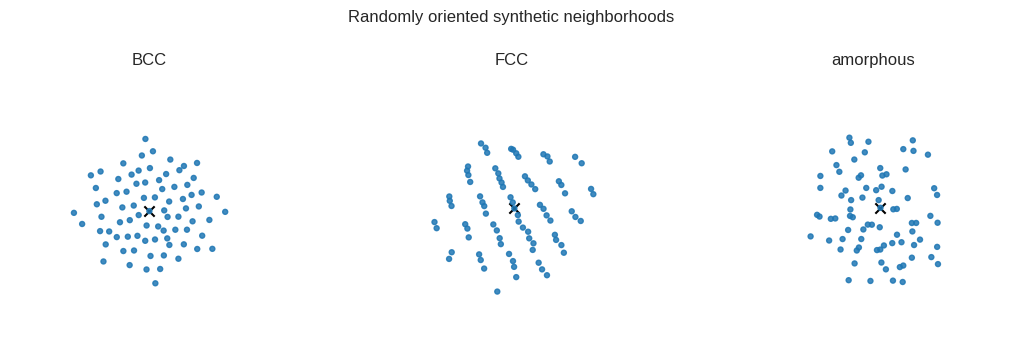

In [5]:
fig = plt.figure(figsize=(11, 3.5))
for class_id, motif in enumerate(MOTIF_NAMES):
    sample_index = int(torch.where(test_labels == class_id)[0][0])
    points = test_points[sample_index].numpy()

    axis = fig.add_subplot(1, NUM_CLASSES, class_id + 1, projection="3d")
    axis.scatter(points[:, 0], points[:, 1], points[:, 2], s=13, alpha=0.85)
    axis.scatter(*points[0], s=55, c="black", marker="x", label="center")
    axis.set_title(motif)
    axis.set_axis_off()
    axis.set_box_aspect((1, 1, 1))

fig.suptitle("Randomly oriented synthetic neighborhoods", y=1.02)
plt.tight_layout()
plt.show()

## 3. Paper encoder and ablation choices

The default `vn_atomic` model is the current GPU-friendly atomic Vector Neuron encoder. Its invariant output concatenates norms of equivariant channels with learned rotation-invariant geometric moments.

Set `ENCODER_VARIANT` in Section 1 to compare against compact VN-DGCNN, VN-PointNet, DGCNN, or PointNet alternatives. Every choice uses the same synthetic split, views, VICReg objective, optimizer, and K-Means evaluation.

`VICRegLoss` owns the view operations used below: nearest-origin cropping, optional shift to one of the nearest atoms, volume-preserving strain, jitter, and point removal.

In [6]:
ENCODER_SPECS = {
    "vn_atomic": (
        "VN_REVNET_Atomic",
        dict(
            latent_size=32,
            k_embed=10,
            k_list=(8, 12),
            embed_channels=16,
            hidden_channels=(32, 48),
            geom_k=10,
            geom_dim=16,
            global_pooling="mean",
            use_batchnorm=True,
        ),
    ),
    "vn_dgcnn": (
        "VN_DGCNN",
        dict(
            latent_size=48,
            n_knn=10,
            feature_dims=(24, 24, 48, 72, 96),
            global_mlp_dims=(96, 64),
            global_dropout=0.0,
            use_batchnorm=True,
            use_cross_product=True,
        ),
    ),
    "vn_pointnet": (
        "PnE_VN",
        dict(
            latent_size=48,
            n_knn=10,
            feature_transform=False,
            hidden_dim1=48,
            hidden_dim2=96,
            use_batchnorm=True,
        ),
    ),
    "dgcnn": (
        "DGCNN",
        dict(
            latent_size=48,
            n_knn=10,
            feature_dims=(24, 24, 48, 72),
            emb_dims=96,
            dropout_rate=0.0,
            use_batchnorm=True,
        ),
    ),
    "pointnet": (
        "PnE_S",
        dict(latent_size=48, feature_transform=False, dropout_rate=0.0),
    ),
}

if ENCODER_VARIANT not in ENCODER_SPECS:
    raise ValueError(
        f"Unknown ENCODER_VARIANT={ENCODER_VARIANT!r}; "
        f"choose one of {sorted(ENCODER_SPECS)}."
    )
encoder_name, encoder_kwargs = ENCODER_SPECS[ENCODER_VARIANT]
encoder = build_encoder(encoder_name, **encoder_kwargs).to(DEVICE)


def prepare_for_encoder(points: torch.Tensor) -> torch.Tensor:
    return prepare_encoder_input(encoder, points)


def select_invariant_output(raw_output):
    output = split_encoder_output(encoder, raw_output)
    return output.invariant, None


vicreg = VICRegLoss(
    enabled=True,
    weight=1.0,
    sim_coeff=25.0,
    std_coeff=25.0,
    cov_coeff=1.0,
    embed_dim=64,
    start_epoch=0,
    jitter_std=0.008,
    jitter_mode="absolute",
    jitter_scale=1.0,
    drop_ratio=0.01,
    view_points=VIEW_POINTS,
    neighbor_view=True,
    neighbor_view_mode="second",
    neighbor_k=6,
    neighbor_max_relative_distance=0.0,
    drop_apply_to_both=True,
    rotation_mode="none",
    rotation_deg=0.0,
    mirror_prob=0.0,
    strain_std=0.01,
    strain_volume_preserve=True,
    occlusion_mode="none",
    occlusion_view="second",
    occlusion_slab_frac=0.2,
    occlusion_cone_deg=20.0,
    occlusion_prob=1.0,
    std_eps=1e-4,
    std_target=1.0,
    input_dim=encoder.invariant_dim,
).to(DEVICE)

parameter_count = sum(
    parameter.numel()
    for parameter in list(encoder.parameters()) + list(vicreg.parameters())
    if parameter.requires_grad
)
print(f"Registry name: {encoder_name}")
print(f"Trainable parameters: {parameter_count:,}")
print(f"Invariant embedding dimension: {encoder.invariant_dim}")

Registry name: VN_REVNET_Atomic
Trainable parameters: 23,521
Invariant embedding dimension: 48


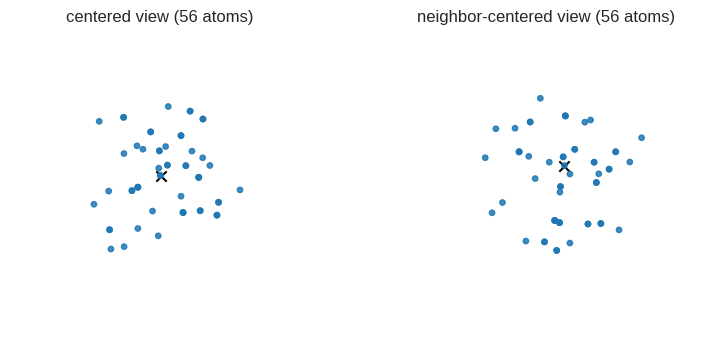

In [7]:
example = train_points[:1].to(DEVICE)
with torch.no_grad():
    centered_view = vicreg._augment(
        example,
        use_neighbor=False,
        apply_occlusion=False,
    )
    neighbor_view = vicreg._augment(
        example,
        use_neighbor=True,
        apply_occlusion=False,
    )

fig = plt.figure(figsize=(8, 3.5))
for panel, (title, view) in enumerate(
    (("centered view", centered_view), ("neighbor-centered view", neighbor_view)),
    start=1,
):
    points = view[0].cpu().numpy()
    axis = fig.add_subplot(1, 2, panel, projection="3d")
    axis.scatter(points[:, 0], points[:, 1], points[:, 2], s=15, alpha=0.85)
    axis.scatter(0, 0, 0, s=55, c="black", marker="x")
    axis.set_title(f"{title} ({len(points)} atoms)")
    axis.set_axis_off()
    axis.set_box_aspect((1, 1, 1))

plt.tight_layout()
plt.show()

## 4. Evaluation helpers

Cluster IDs are arbitrary, so accuracy uses Hungarian matching. NMI and ARI are already permutation-invariant. Rotation error compares embeddings of the same held-out clouds before and after an independent SO(3) rotation.

In [8]:
@torch.no_grad()
def extract_embeddings(
    points: torch.Tensor,
    *,
    apply_fresh_rotation: bool = False,
) -> np.ndarray:
    encoder.eval()
    embeddings = []

    loader = DataLoader(TensorDataset(points), batch_size=128, shuffle=False)
    for (batch,) in loader:
        batch = crop_to_num_points(batch.to(DEVICE), VIEW_POINTS)
        if apply_fresh_rotation:
            rotations = vicreg._random_rotation_matrices(
                len(batch),
                device=DEVICE,
                dtype=batch.dtype,
            )
            batch = torch.bmm(batch, rotations.transpose(1, 2))

        output = encode_point_clouds(encoder, batch)
        embeddings.append(output.invariant.float().cpu())

    return torch.cat(embeddings).numpy()


def evaluate_clustering(points: torch.Tensor, labels: torch.Tensor):
    embeddings = extract_embeddings(points)
    predictions = KMeans(
        n_clusters=NUM_CLASSES,
        init="k-means++",
        n_init=20,
        random_state=SEED,
    ).fit_predict(embeddings)

    labels_numpy = labels.numpy()
    contingency = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    for true_class, cluster_id in zip(labels_numpy, predictions):
        contingency[true_class, cluster_id] += 1

    true_ids, cluster_ids = linear_sum_assignment(-contingency)
    cluster_to_class = {
        cluster_id: true_id
        for true_id, cluster_id in zip(true_ids, cluster_ids)
    }
    aligned_predictions = np.array(
        [cluster_to_class[cluster_id] for cluster_id in predictions]
    )

    rotated_embeddings = extract_embeddings(
        points,
        apply_fresh_rotation=True,
    )
    relative_rotation_error = np.linalg.norm(
        embeddings - rotated_embeddings,
        axis=1,
    ) / (np.linalg.norm(embeddings, axis=1) + 1e-9)

    return {
        "embeddings": embeddings,
        "aligned_predictions": aligned_predictions,
        "accuracy": float(np.mean(aligned_predictions == labels_numpy)),
        "nmi": float(normalized_mutual_info_score(labels_numpy, predictions)),
        "ari": float(adjusted_rand_score(labels_numpy, predictions)),
        "rotation_error_mean": float(relative_rotation_error.mean()),
        "rotation_error_max": float(relative_rotation_error.max()),
    }


def print_metrics(title: str, result: dict) -> None:
    print(title)
    print(f"  Hungarian-matched ACC: {result['accuracy']:.3f}")
    print(f"  NMI:                   {result['nmi']:.3f}")
    print(f"  ARI:                   {result['ari']:.3f}")
    print(
        "  rotation error:        "
        f"mean={result['rotation_error_mean']:.2e}, "
        f"max={result['rotation_error_max']:.2e}"
    )

In [9]:
initial_result = evaluate_clustering(test_points, test_labels)
print_metrics("Before self-supervised training", initial_result)

Before self-supervised training
  Hungarian-matched ACC: 0.517
  NMI:                   0.558
  ARI:                   0.381
  rotation error:        mean=4.26e-07, max=7.18e-07


## 5. Self-supervised VICReg training

The DataLoader below contains only point clouds. It does **not** contain `train_labels`.

The small adapter selects each encoder's declared invariant output, so all alternatives share the same projector and VICReg objective. The VICReg projector is trained jointly but discarded for evaluation.

In [10]:
unlabeled_train_loader = DataLoader(
    TensorDataset(train_points),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    generator=torch.Generator().manual_seed(SEED),
)

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(vicreg.parameters()),
    lr=3e-3,
    weight_decay=1e-5,
)

loss_history = []
start_time = time.perf_counter()

for epoch in range(EPOCHS):
    encoder.train()
    vicreg.train()
    epoch_loss = 0.0

    for (point_batch,) in unlabeled_train_loader:
        point_batch = point_batch.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        loss, _ = vicreg.compute_loss(
            pc=point_batch,
            encoder=encoder,
            prepare_input=prepare_for_encoder,
            split_output=select_invariant_output,
            current_epoch=epoch,
        )
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite or missing VICReg loss at epoch {epoch + 1}: {loss}"
            )

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    mean_epoch_loss = epoch_loss / len(unlabeled_train_loader)
    loss_history.append(mean_epoch_loss)
    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1:02d}/{EPOCHS}: loss={mean_epoch_loss:.4f}")

elapsed = time.perf_counter() - start_time
print(f"Training time: {elapsed:.1f} s on {DEVICE}")

epoch 01/60: loss=22.1893


epoch 10/60: loss=16.5551


epoch 20/60: loss=16.4568


epoch 30/60: loss=16.4618


epoch 40/60: loss=16.4130


epoch 50/60: loss=16.4554


epoch 60/60: loss=16.4187
Training time: 12.2 s on cuda


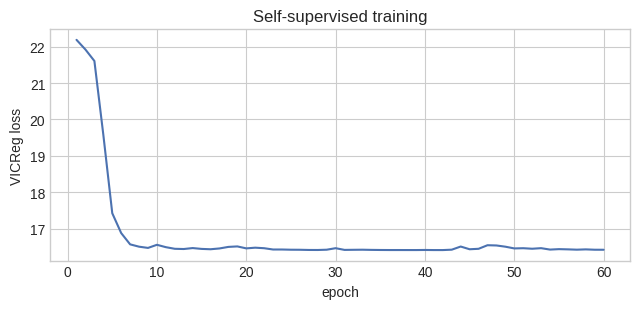

In [11]:
plt.figure(figsize=(6.5, 3.2))
plt.plot(np.arange(1, EPOCHS + 1), loss_history, color="#4C72B0")
plt.xlabel("epoch")
plt.ylabel("VICReg loss")
plt.title("Self-supervised training")
plt.tight_layout()
plt.show()

## 6. Freeze, cluster, and test SO(3) robustness

Labels enter only now, after the encoder has been trained and frozen.

In [12]:
final_result = evaluate_clustering(test_points, test_labels)
print_metrics("After self-supervised training", final_result)

After self-supervised training
  Hungarian-matched ACC: 0.967
  NMI:                   0.881
  ARI:                   0.904
  rotation error:        mean=8.49e-07, max=2.27e-06


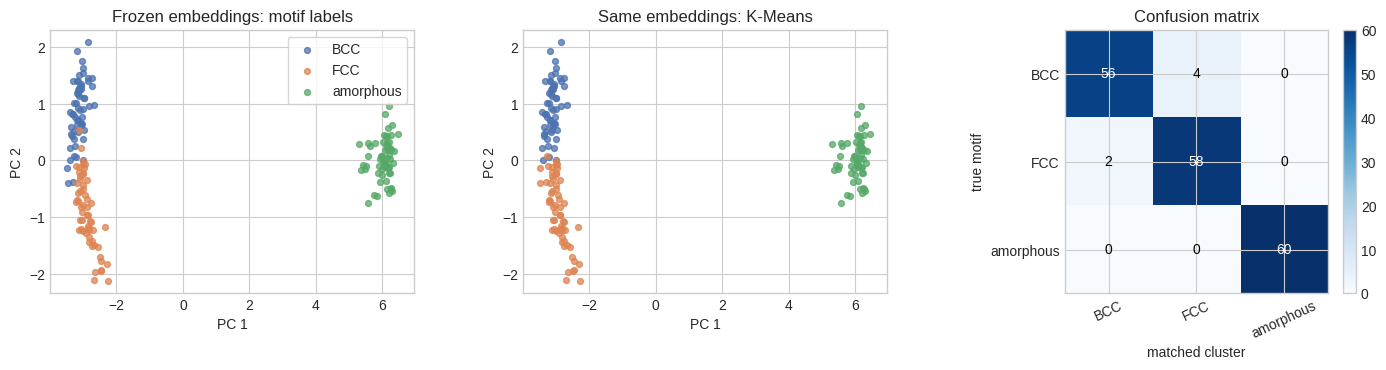

In [13]:
embedding_2d = PCA(n_components=2, random_state=SEED).fit_transform(
    final_result["embeddings"]
)
true_labels = test_labels.numpy()
predicted_labels = final_result["aligned_predictions"]
matrix = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
)

colors = ("#4C72B0", "#DD8452", "#55A868")
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for class_id, (name, color) in enumerate(zip(MOTIF_NAMES, colors)):
    mask = true_labels == class_id
    axes[0].scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        s=18,
        alpha=0.75,
        label=name,
        color=color,
    )
axes[0].set_title("Frozen embeddings: motif labels")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].legend(frameon=True)

for class_id, (name, color) in enumerate(zip(MOTIF_NAMES, colors)):
    mask = predicted_labels == class_id
    axes[1].scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        s=18,
        alpha=0.75,
        label=name,
        color=color,
    )
axes[1].set_title("Same embeddings: K-Means")
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")

image = axes[2].imshow(matrix, cmap="Blues")
for row in range(NUM_CLASSES):
    for column in range(NUM_CLASSES):
        axes[2].text(
            column,
            row,
            str(matrix[row, column]),
            ha="center",
            va="center",
            color="white" if matrix[row, column] > matrix.max() / 2 else "black",
        )
axes[2].set_xticks(np.arange(NUM_CLASSES), MOTIF_NAMES, rotation=25)
axes[2].set_yticks(np.arange(NUM_CLASSES), MOTIF_NAMES)
axes[2].set_xlabel("matched cluster")
axes[2].set_ylabel("true motif")
axes[2].set_title("Confusion matrix")
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## What this demonstrates

- The optimizer never sees motif labels.
- Neighbor-centered views reuse the repository's spatial view construction.
- The default atomic VN embedding is unchanged, up to floating-point error, by fresh global rotations.
- A plain K-Means fit on frozen embeddings recovers the synthetic motifs.
- Paper-relevant encoder alternatives can be compared by changing one explicit setting.

This is intentionally a fast qualitative and integration check. Reproducing the paper's four-class metrics requires the full polycrystal generator, HCP neighborhoods, the paper-scale encoder/views, multiple seeds, and the evaluation protocol preserved on the `paper_version` branch.